In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import os

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully!")

ModuleNotFoundError: No module named 'wordcloud'

In [2]:
%pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
from wordcloud import WordCloud

print("WordCloud imported successfully!")

ModuleNotFoundError: No module named 'wordcloud'

In [4]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [5]:
import sys
!{sys.executable} -m pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [1]:
from wordcloud import WordCloud

print("WordCloud imported successfully!")

WordCloud imported successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import os

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv("../dataset/IMDB_Dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/IMDB_Dataset.csv'

In [4]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
D:\ML\Sentiment_Analysis_Project\notebook


In [5]:
print(os.listdir())

['.ipynb_checkpoints', 'Untitled.ipynb']


In [8]:
import os

print(os.listdir(".."))

['.ipynb_checkpoints', 'dataset', 'notebook']


In [7]:
df = pd.read_csv("../dataset/IMDB_Dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/IMDB_Dataset.csv'

In [9]:
import os

print(os.listdir("dataset"))


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'dataset'

In [10]:
import os

current = os.getcwd()

print("Current folder:")
print(current)

print("\nFiles/folders one level up:")
print(os.listdir(".."))

print("\nFiles/folders two levels up:")
print(os.listdir("../.."))

Current folder:
D:\ML\Sentiment_Analysis_Project\notebook

Files/folders one level up:
['.ipynb_checkpoints', 'dataset', 'notebook']

Files/folders two levels up:
['.ipynb_checkpoints', 'anaconda_projects', 'column_2C_weka.arff', 'column_3C.dat', 'column_3C_weka.arff', 'digits.csv', 'Experiment 2.ipynb', 'experiment 4.ipynb', 'Experiment1.ipynb', 'IMDB Dataset.csv.zip', 'KDDTest+.arff', 'Sentiment_Analysis_Project', 'Untitled Folder', 'Untitled Folder 1', 'Untitled.ipynb', 'untitled.py', 'Untitled1.ipynb', 'untitled1.py', 'Untitled2.ipynb', 'untitled2.py', 'vertebral_column_data.dat', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [14]:
df = pd.read_csv("../dataset/IMDB Dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [15]:
print("Column names:")
print(df.columns.tolist())

Column names:
['review', 'sentiment']


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [17]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
review       0
sentiment    0
dtype: int64


In [18]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
418


In [19]:
print("Sentiment distribution:")
print(df["sentiment"].value_counts())

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [20]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 50000
Rows after removing duplicates: 49582
Duplicates removed: 418


In [21]:
print("Final dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Final dataset shape: (49582, 2)

Missing values:
review       0
sentiment    0
dtype: int64


In [22]:
print(df.columns.tolist())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df["sentiment"].value_counts())
print(df.shape)

['review', 'sentiment']
review       0
sentiment    0
dtype: int64
0
sentiment
positive    24884
negative    24698
Name: count, dtype: int64
(49582, 2)


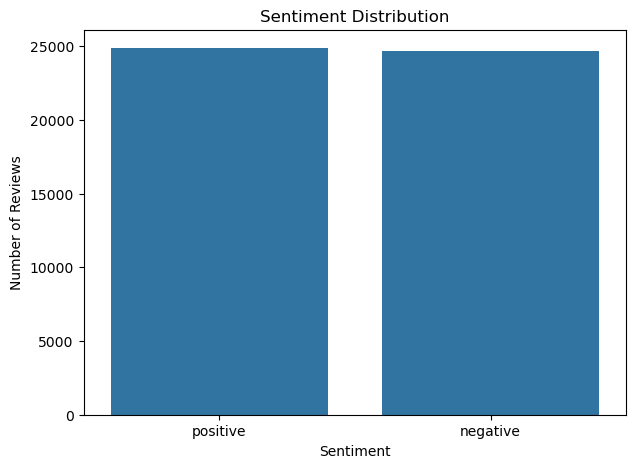

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [24]:
sentiment_percentage = (
    df["sentiment"]
    .value_counts(normalize=True) * 100
)

print("Sentiment Percentage:")
print(sentiment_percentage.round(2))

Sentiment Percentage:
sentiment
positive    50.19
negative    49.81
Name: proportion, dtype: float64


In [25]:
df["review_length"] = df["review"].apply(len)

print(df["review_length"].describe())

count    49582.000000
mean      1310.568230
std        990.762238
min         32.000000
25%        699.000000
50%        971.000000
75%       1592.000000
max      13704.000000
Name: review_length, dtype: float64


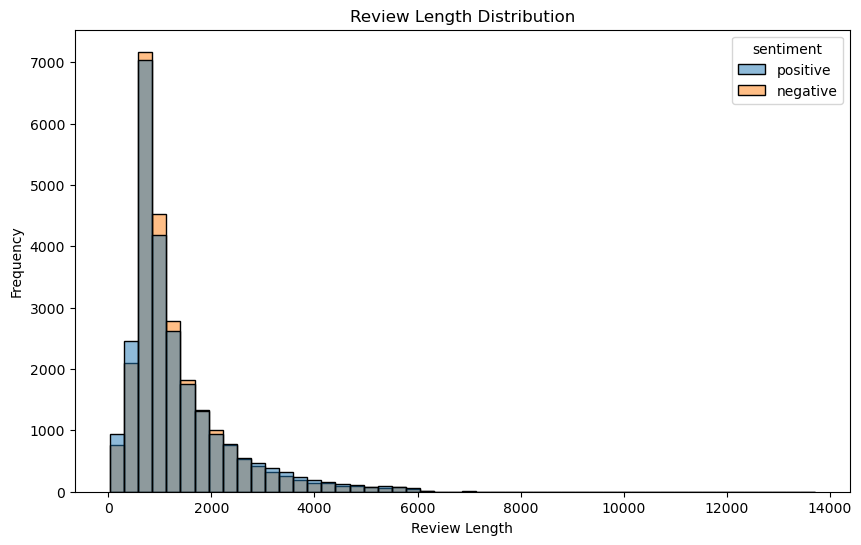

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="review_length",
    hue="sentiment",
    bins=50
)

plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.show()

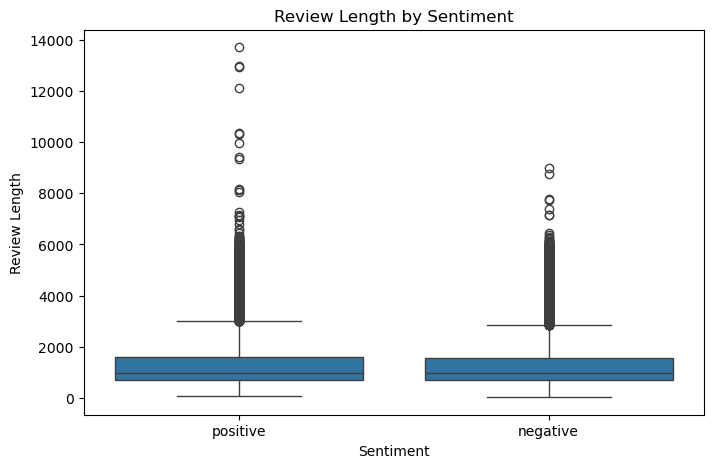

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="sentiment",
    y="review_length"
)

plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length")

plt.show()

In [28]:
print("POSITIVE REVIEWS\n")

positive_reviews = df[
    df["sentiment"] == "positive"
]["review"].head(5)

for i, review in enumerate(positive_reviews, 1):
    print(f"{i}. {review[:500]}")
    print("-" * 80)

POSITIVE REVIEWS

1. One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ
--------------------------------------------------------------------------------
2. A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the r

In [29]:
print("NEGATIVE REVIEWS\n")

negative_reviews = df[
    df["sentiment"] == "negative"
]["review"].head(5)

for i, review in enumerate(negative_reviews, 1):
    print(f"{i}. {review[:500]}")
    print("-" * 80)

NEGATIVE REVIEWS

1. Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins 
--------------------------------------------------------------------------------
2. This show was an amazing, fresh & innovative idea in the 70's when it first aired. The first 7 or 8 years were brilliant, but things dropped off after that. By 1990, the show was not really funny anymore, and it's continued its decline further to the complete waste of time it is today.<br /><br />It's truly disgraceful how far this show has fallen. The writing is painfully bad, the performan

In [30]:
def clean_text(text):
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )
    
    # Remove special characters and numbers
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )
    
    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()
    
    return text

In [31]:
sample = df["review"].iloc[1]

print("ORIGINAL REVIEW:")
print(sample)

print("\n" + "=" * 80)

print("CLEANED REVIEW:")
print(clean_text(sample))

ORIGINAL REVIEW:
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terr

In [32]:
df["clean_review"] = df["review"].apply(clean_text)

print("Text preprocessing completed!")

Text preprocessing completed!


In [33]:
df[["review", "clean_review", "sentiment"]].head()

,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,positive
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...,positive


In [34]:
for i in range(3):
    
    print("ORIGINAL:")
    print(df["review"].iloc[i][:300])
    
    print("\nCLEANED:")
    print(df["clean_review"].iloc[i][:300])
    
    print("\n" + "=" * 100 + "\n")

ORIGINAL:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

CLEANED:
one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not 


ORIGINAL:
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" 

CLEANED:
a wonderful little production the filming technique is 

In [35]:
df[["review", "clean_review", "sentiment"]].head()

,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,positive
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...,positive


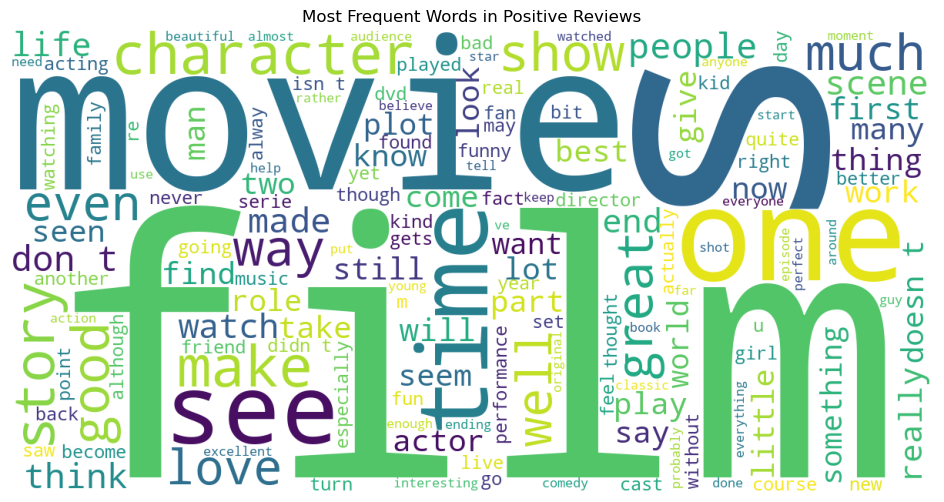

In [36]:
positive_text = " ".join(
    df[df["sentiment"] == "positive"]["clean_review"]
)

wordcloud_positive = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=150
).generate(positive_text)

plt.figure(figsize=(12, 6))

plt.imshow(wordcloud_positive)

plt.axis("off")

plt.title("Most Frequent Words in Positive Reviews")

plt.show()

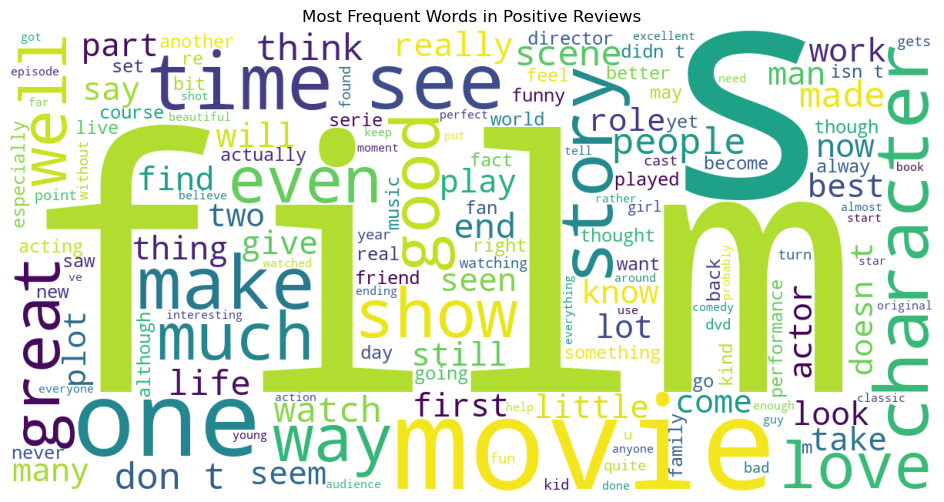

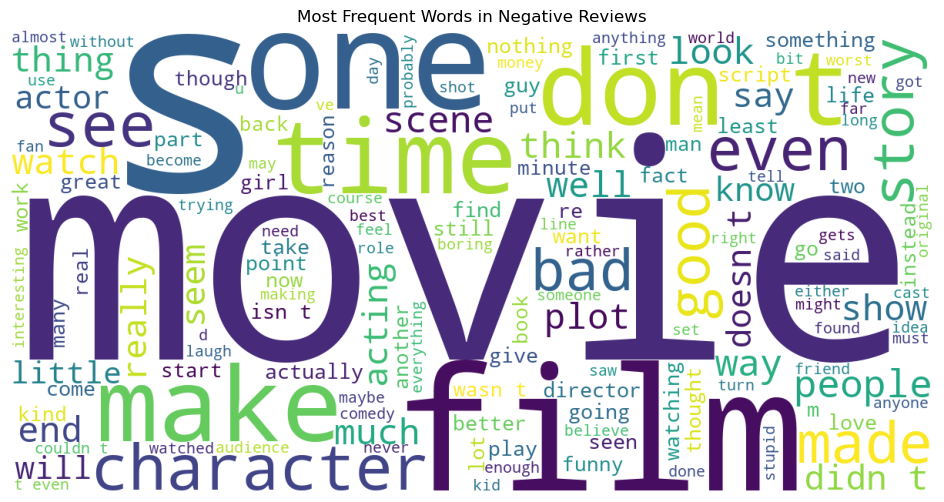

In [38]:
negative_text = " ".join(
    df[df["sentiment"] == "negative"]["clean_review"]
)

wordcloud_negative = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=150
).generate(negative_text)

plt.figure(figsize=(12, 6))

plt.imshow(wordcloud_negative)

plt.axis("off")

plt.title("Most Frequent Words in Negative Reviews")

plt.show()

In [39]:
os.makedirs("../images", exist_ok=True)

In [40]:
wordcloud_positive.to_file(
    "../images/positive_wordcloud.png"
)

print("Positive word cloud saved!")

Positive word cloud saved!


In [41]:
wordcloud_negative.to_file(
    "../images/negative_wordcloud.png"
)

print("Negative word cloud saved!")

Negative word cloud saved!


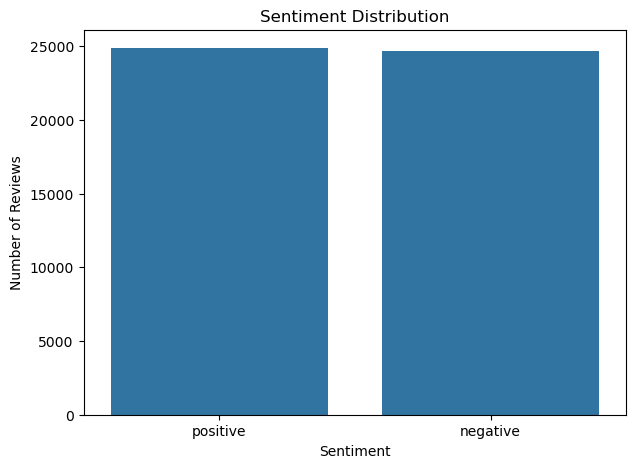

In [42]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.savefig(
    "../images/sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

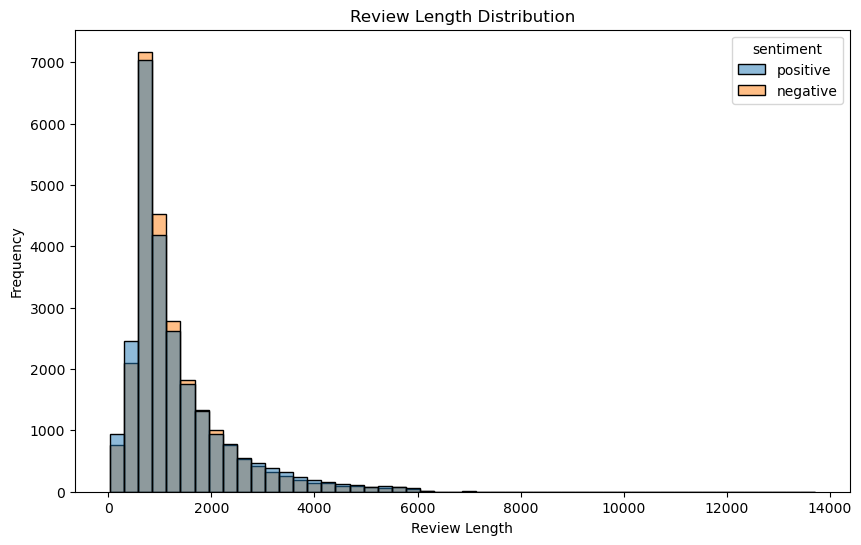

In [43]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="review_length",
    hue="sentiment",
    bins=50
)

plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.savefig(
    "../images/review_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

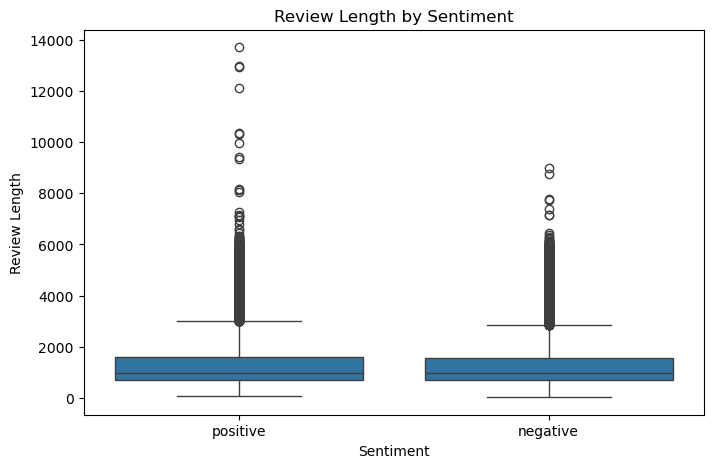

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="sentiment",
    y="review_length"
)

plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length")

plt.savefig(
    "../images/review_length_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
df["sentiment"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

In [46]:
print(df["sentiment"].value_counts())

sentiment
1    24884
0    24698
Name: count, dtype: int64


In [47]:
X = df["clean_review"]
y = df["sentiment"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (49582,)
Target: (49582,)


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 39665
Testing samples: 9917


In [49]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF transformation completed!")
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

TF-IDF transformation completed!
Training shape: (39665, 50000)
Testing shape: (9917, 50000)


In [50]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr.predict(
    X_test_tfidf
)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [51]:
lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_precision = precision_score(
    y_test,
    lr_pred
)

lr_recall = recall_score(
    y_test,
    lr_pred
)

lr_f1 = f1_score(
    y_test,
    lr_pred
)

print("Logistic Regression Results")
print("-" * 40)

print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))

Logistic Regression Results
----------------------------------------
Accuracy : 0.9072
Precision: 0.8958
Recall   : 0.9224
F1 Score : 0.9089


In [52]:
nb = MultinomialNB()

nb.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb.predict(
    X_test_tfidf
)

print("Naive Bayes training completed!")

Naive Bayes training completed!


In [53]:
nb_accuracy = accuracy_score(
    y_test,
    nb_pred
)

nb_precision = precision_score(
    y_test,
    nb_pred
)

nb_recall = recall_score(
    y_test,
    nb_pred
)

nb_f1 = f1_score(
    y_test,
    nb_pred
)

print("Naive Bayes Results")
print("-" * 40)

print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1 Score :", round(nb_f1, 4))

Naive Bayes Results
----------------------------------------
Accuracy : 0.8832
Precision: 0.8797
Recall   : 0.8889
F1 Score : 0.8843


In [54]:
svm = LinearSVC(
    random_state=42
)

svm.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm.predict(
    X_test_tfidf
)

print("Linear SVM training completed!")

Linear SVM training completed!


In [55]:
svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

svm_precision = precision_score(
    y_test,
    svm_pred
)

svm_recall = recall_score(
    y_test,
    svm_pred
)

svm_f1 = f1_score(
    y_test,
    svm_pred
)

print("Linear SVM Results")
print("-" * 40)

print("Accuracy :", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall   :", round(svm_recall, 4))
print("F1 Score :", round(svm_f1, 4))

Linear SVM Results
----------------------------------------
Accuracy : 0.9079
Precision: 0.9035
Recall   : 0.9142
F1 Score : 0.9088


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Starting Random Forest training...")

rf.fit(
    X_train_tfidf,
    y_train
)

print("Random Forest training completed!")

rf_pred = rf.predict(X_test_tfidf)

print("Prediction completed!")

In [72]:
rf = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

print("Starting Random Forest...")

rf.fit(X_train_tfidf, y_train)

print("Random Forest training completed!")

rf_pred = rf.predict(X_test_tfidf)

print("Prediction completed!")

Starting Random Forest...
Random Forest training completed!
Prediction completed!


In [73]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

print("Random Forest Results")
print("-" * 40)

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Random Forest Results
----------------------------------------
Accuracy : 0.839
Precision: 0.8442
Recall   : 0.8328
F1 Score : 0.8385


In [74]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "Random Forest"
    ],
    
    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        svm_accuracy,
        rf_accuracy
    ],
    
    "Precision": [
        lr_precision,
        nb_precision,
        svm_precision,
        rf_precision
    ],
    
    "Recall": [
        lr_recall,
        nb_recall,
        svm_recall,
        rf_recall
    ],
    
    "F1 Score": [
        lr_f1,
        nb_f1,
        svm_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.907230,0.895805,0.922443,0.908929
1,Naive Bayes,0.883231,0.879698,0.888889,0.884269
2,Linear SVM,0.907936,0.903495,0.914205,0.908819
3,Random Forest,0.838963,0.844196,0.832831,0.838475


<Figure size 1200x600 with 0 Axes>

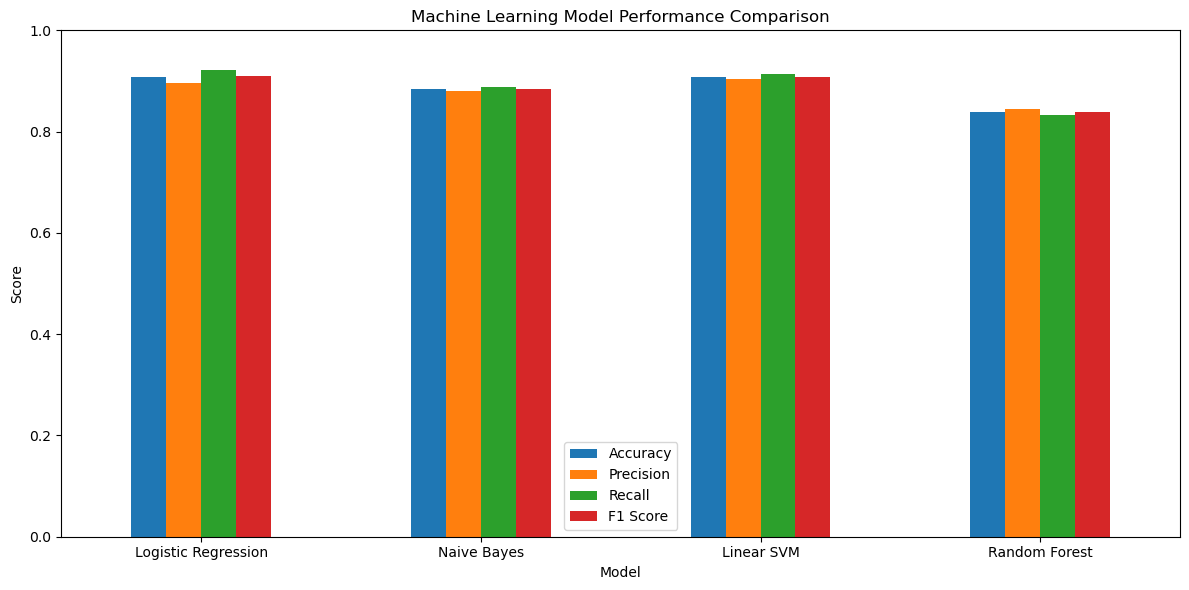

In [75]:
plt.figure(figsize=(12, 6))

results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [76]:
best_model = results.loc[
    results["F1 Score"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model        Logistic Regression
Accuracy                 0.90723
Precision               0.895805
Recall                  0.922443
F1 Score                0.908929
Name: 0, dtype: object


In [77]:
print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.907230   0.895805  0.922443  0.908929
1          Naive Bayes  0.883231   0.879698  0.888889  0.884269
2           Linear SVM  0.907936   0.903495  0.914205  0.908819
3        Random Forest  0.838963   0.844196  0.832831  0.838475


In [78]:
print("Linear SVM Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        svm_pred,
        target_names=["Negative", "Positive"]
    )
)

Linear SVM Classification Report
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.91      4940
    Positive       0.90      0.91      0.91      4977

    accuracy                           0.91      9917
   macro avg       0.91      0.91      0.91      9917
weighted avg       0.91      0.91      0.91      9917



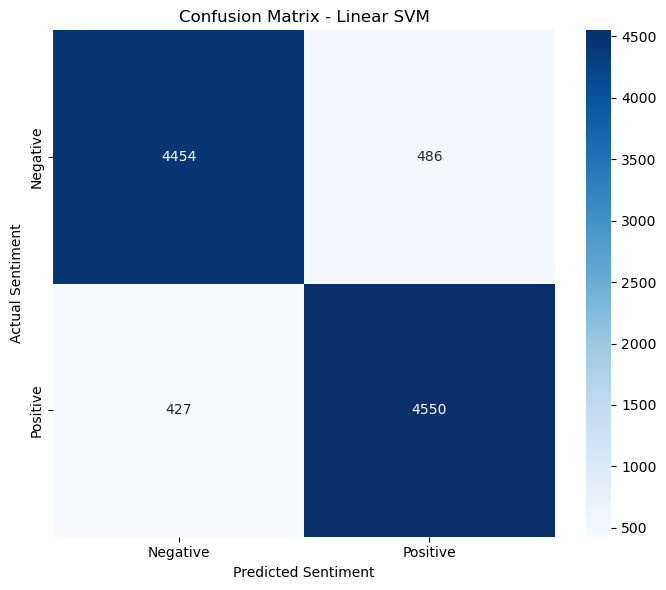

In [79]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.tight_layout()

plt.savefig(
    "../images/confusion_matrix_svm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [80]:
error_analysis = pd.DataFrame({
    "review": X_test,
    "actual": y_test,
    "predicted": svm_pred
})

errors = error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
]

print("Number of misclassified reviews:", len(errors))
print("Error percentage:",
      round(len(errors) / len(y_test) * 100, 2), "%")

Number of misclassified reviews: 913
Error percentage: 9.21 %


In [81]:
errors.head(10)

,review,actual,predicted
34722,despite being a huge fan of fred astaire and g...,0,1
26602,i know that full moon or any other film studio...,0,1
27228,well well roeg touched a bit of a nerve there ...,1,0
34021,ok let me again admit that i haven t seen any ...,0,1
14432,i m not here to tell you armored is kubrickian...,1,0
12446,this movie probably had a budget and still man...,1,0
38057,stodgy drama starring pat o brien as a washed ...,0,1
31715,i was excited to hear that someone had made a ...,0,1
15261,saving grace is never riotously funny but it d...,1,0
29439,financially strapped paramount pulled out all ...,1,0


In [82]:
svm_param_grid = {
    "C": [0.5, 1, 1.5, 2]
}

In [83]:
svm_grid = GridSearchCV(
    LinearSVC(random_state=42),
    svm_param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_tfidf, y_train)

print("Best parameters:")
print(svm_grid.best_params_)

print("\nBest cross-validation F1 score:")
print(svm_grid.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters:
{'C': 0.5}

Best cross-validation F1 score:
0.9097446646706541


In [84]:
tuned_svm = svm_grid.best_estimator_

tuned_pred = tuned_svm.predict(X_test_tfidf)

tuned_accuracy = accuracy_score(
    y_test,
    tuned_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_pred
)

tuned_recall = recall_score(
    y_test,
    tuned_pred
)

tuned_f1 = f1_score(
    y_test,
    tuned_pred
)

print("Tuned Linear SVM Results")
print("=" * 40)

print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1 Score :", round(tuned_f1, 4))

Tuned Linear SVM Results
Accuracy : 0.9102
Precision: 0.9046
Recall   : 0.9178
F1 Score : 0.9111


In [85]:
print("Original SVM Accuracy :", round(svm_accuracy, 4))
print("Tuned SVM Accuracy    :", round(tuned_accuracy, 4))

print("\nOriginal SVM F1 Score :", round(svm_f1, 4))
print("Tuned SVM F1 Score    :", round(tuned_f1, 4))

Original SVM Accuracy : 0.9079
Tuned SVM Accuracy    : 0.9102

Original SVM F1 Score : 0.9088
Tuned SVM F1 Score    : 0.9111


In [86]:
print(svm_grid.best_params_)
print(svm_grid.best_score_)
print(tuned_accuracy)
print(tuned_precision)
print(tuned_recall)
print(tuned_f1)

{'C': 0.5}
0.9097446646706541
0.9101542805283857
0.9045544554455446
0.9178219811131203
0.9111399222100329


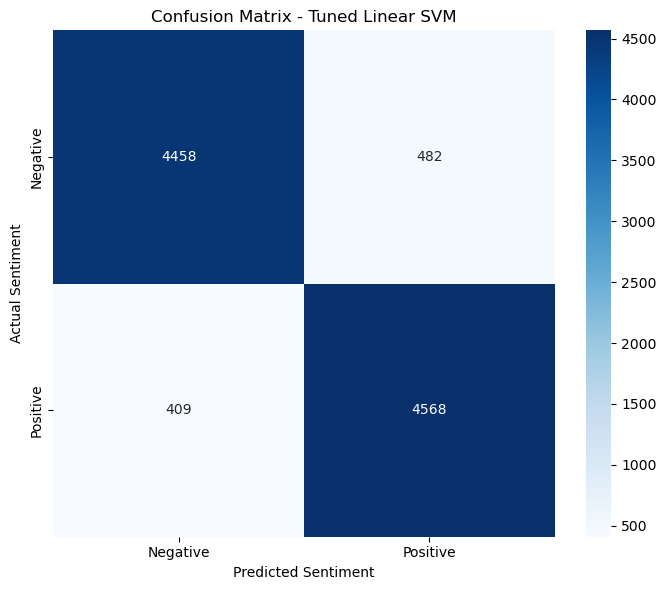

In [87]:
final_cm = confusion_matrix(y_test, tuned_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix - Tuned Linear SVM")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.tight_layout()

plt.savefig(
    "../images/final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [88]:
print("FINAL MODEL - TUNED LINEAR SVM")
print("=" * 55)

print(
    classification_report(
        y_test,
        tuned_pred,
        target_names=["Negative", "Positive"]
    )
)

FINAL MODEL - TUNED LINEAR SVM
              precision    recall  f1-score   support

    Negative       0.92      0.90      0.91      4940
    Positive       0.90      0.92      0.91      4977

    accuracy                           0.91      9917
   macro avg       0.91      0.91      0.91      9917
weighted avg       0.91      0.91      0.91      9917



In [89]:
final_model = tuned_svm

print("Final model selected: Tuned Linear SVM")
print("Best parameter:", svm_grid.best_params_)

Final model selected: Tuned Linear SVM
Best parameter: {'C': 0.5}


In [90]:
joblib.dump(
    final_model,
    "../models/sentiment_model.pkl"
)

joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

print("Model saved successfully!")
print("TF-IDF vectorizer saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '../models/sentiment_model.pkl'

In [91]:
sentiment_model.pkl
tfidf_vectorizer.pkl

NameError: name 'sentiment_model' is not defined

In [92]:
import os

print("Current folder:")
print(os.getcwd())

print("\nOne level up:")
print(os.listdir(".."))

Current folder:
D:\ML\Sentiment_Analysis_Project\notebook

One level up:
['.ipynb_checkpoints', 'dataset', 'images', 'notebook']


In [93]:
import os

os.makedirs("../models", exist_ok=True)
os.makedirs("../app", exist_ok=True)
os.makedirs("../images", exist_ok=True)

print("Required folders created successfully!")

Required folders created successfully!


In [94]:
joblib.dump(
    final_model,
    "../models/sentiment_model.pkl"
)

joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

print("Model saved successfully!")
print("TF-IDF vectorizer saved successfully!")

Model saved successfully!
TF-IDF vectorizer saved successfully!


In [95]:
print(
    "Model exists:",
    os.path.exists("../models/sentiment_model.pkl")
)

print(
    "Vectorizer exists:",
    os.path.exists("../models/tfidf_vectorizer.pkl")
)

Model exists: True
Vectorizer exists: True


In [96]:
loaded_model = joblib.load(
    "../models/sentiment_model.pkl"
)

loaded_tfidf = joblib.load(
    "../models/tfidf_vectorizer.pkl"
)

print("Saved model loaded successfully!")
print("Saved vectorizer loaded successfully!")

Saved model loaded successfully!
Saved vectorizer loaded successfully!


In [97]:
test_review = "This movie was absolutely wonderful and I really enjoyed it!"

cleaned_test = clean_text(test_review)

test_vector = loaded_tfidf.transform(
    [cleaned_test]
)

prediction = loaded_model.predict(
    test_vector
)[0]

if prediction == 1:
    print("Prediction: POSITIVE 😊")
else:
    print("Prediction: NEGATIVE 😞")

Prediction: POSITIVE 😊


In [98]:
test_review = "This movie was boring, disappointing and a complete waste of time."

cleaned_test = clean_text(test_review)

test_vector = loaded_tfidf.transform(
    [cleaned_test]
)

prediction = loaded_model.predict(
    test_vector
)[0]

if prediction == 1:
    print("Prediction: POSITIVE 😊")
else:
    print("Prediction: NEGATIVE 😞")

Prediction: NEGATIVE 😞
